1.1.1 What are Recommendation Systems?
Recommendation Systems are software tools and algorithms that provide suggestions 
for products, services, or information to users. The suggestions are tailored to the user’s preferences, based on data about their previous behavior and preferences.

The underlying function of a recommendation system can be represented as:

    f : User x Item -> Rating
 
f: represents the predictive function that estimates the utility (or rating) of an item for a particular user.

User: represents the set of all users in the system. Each user is a potential recipient of recommendations.

Item: represents the set of all items available for recommendation. 
These can include products, services, media content, or any other entities that the system recommends.

Rating: represents predicted rating or preference score that a user would give to an item, 
which can be used to generate personalized recommendations.

Types of Recommendation Systems
There are three types of recommendation systems, each utilizing different techniques
to generate personalized recommendations:

Collaborative filtering
Content filtering
Hybrid filtering

1.3.1 Collaborative Filtering
Collaborative filtering algorithms recommend items by analyzing user preferences collected from numerous users.
They predict future behavior by identifying patterns in historical data, such as which movies users have enjoyed,
allowing the system to suggest items with a high likelihood of user agreement.

For example, if two users have similar tastes in movies, the system might recommend a new movie to one user
that the other has favorably rated.

Mathematical Concept:
To quantify the similarity between user preferences, collaborative filtering uses cosine similarity, 
where user ratings are vectors in a multidimensional space:
 
Where:

similarity = cos(theta) = A.B / |A| |B|
 
and A and B are vectors representing user ratings.
Theta is the angle between these vectors, which indicates the degree of similarity in user preferences.
A smaller angle (or higher cosine similarity) indicates more closely aligned preferences, 
suggesting that users will likely enjoy similar items. This approach enables more precise 
recommendations based on shared user interests.

There are mainly two types of collaborative filtering techniques:

Memory-based collaborative filtering
Model-based collaborative filtering

3.1.1 Memory-Based Collaborative Filtering
Memory-based collaborative filtering is a fundamental approach within recommendation systems that generates predictions based on the entire database of user-item interactions. This method leverages historical data from user ratings to recommend new items or predict user ratings. It operates on the assumption that those who agreed in the past will agree again in the future.

There are two primary strategies within memory-based collaborative filtering:

User-based collaborative filtering
Item-based collaborative filtering

User-Based Collaborative Filtering
User-based collaborative filtering is a recommendation technique that suggests items or content 
to a target user based on the preferences and behaviors of similar users. 
It operates under the assumption that users who have interacted with similar items in the past
will continue to have similar preferences in the future.

In [38]:
import pandas as pd
animes = pd.read_csv('anime.csv')
print(animes.head())
print(animes.info())

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  

In [40]:
animes.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [42]:
# handle missing values
animes['genre'].fillna('Unknown', inplace=True)
animes['type'].fillna('Unknown', inplace=True)
animes['episodes'] = pd.to_numeric(animes['episodes'], errors='coerce').fillna(0)
animes['rating'].fillna(animes['rating'].mean(), inplace=True)

C:\Users\Vandana\AppData\Local\Temp\ipykernel_23072\996944643.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  animes['genre'].fillna('Unknown', inplace=True)
C:\Users\Vandana\AppData\Local\Temp\ipykernel_23072\996944643.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [44]:
animes.describe()

,anime_id,episodes,rating,members
count,12294.000000,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,12.040101,6.473902,1.807134e+04
std,11455.294701,46.257299,1.017096,5.482068e+04
min,1.000000,0.000000,1.670000,5.000000e+00
25%,3484.250000,1.000000,5.900000,2.250000e+02
50%,10260.500000,2.000000,6.550000,1.550000e+03
75%,24794.500000,12.000000,7.170000,9.437000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


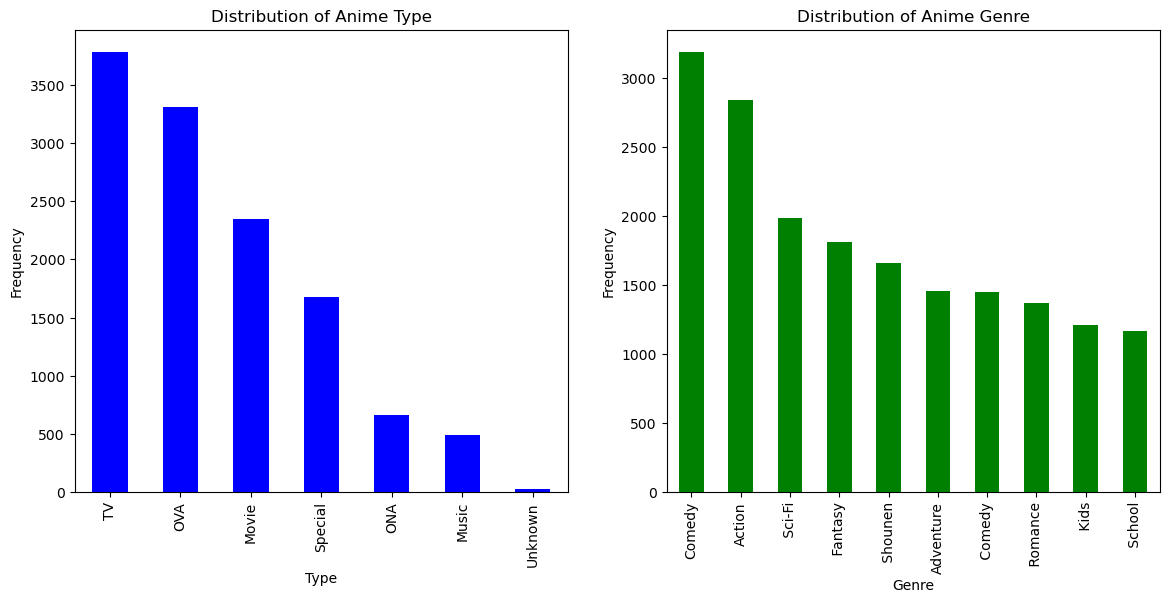

In [46]:
# Analyaze the categorical variables 
import matplotlib.pyplot as plt

type_counts = animes['type'].value_counts()
genre_counts = animes['genre'].str.split(',').explode().value_counts().head(10)

# plot 
fig, ax = plt.subplots(1,2,figsize=(14,6))

type_counts.plot(kind='bar', ax=ax[0], color='blue')
ax[0].set_title('Distribution of Anime Type')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Type')

genre_counts.plot(kind='bar', ax=ax[1], color='green')
ax[1].set_title('Distribution of Anime Genre')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Genre')

plt.show()

In [50]:
# EDA on rating dataset
ratings = pd.read_csv('rating.csv')

In [54]:
# -1 -> imply missing values
# Exclude -1 values from ratings df
ratings = ratings[ratings.rating != -1]
ratings.head(10)

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10
156,3,20,8
157,3,154,6
158,3,170,9
159,3,199,10
160,3,225,9


In [56]:
# Check for missing values
ratings.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [58]:
len(ratings)

6337241

In [60]:
# Cal the number of unique user Ids in ratings dataset
len(ratings['user_id'].unique())

69600

In [64]:
# Cal number of unique anime ids
len(ratings['anime_id'].unique())

9927

In [66]:
import statistics
# Cal number of ratings per user - group by 
ratings_per_user = ratings.groupby('user_id')['rating'].count()
# Cal the mean no.of ratings per user
mean_ratings_per_user = statistics.mean(ratings_per_user.tolist())
mean_ratings_per_user

91.05231321839081

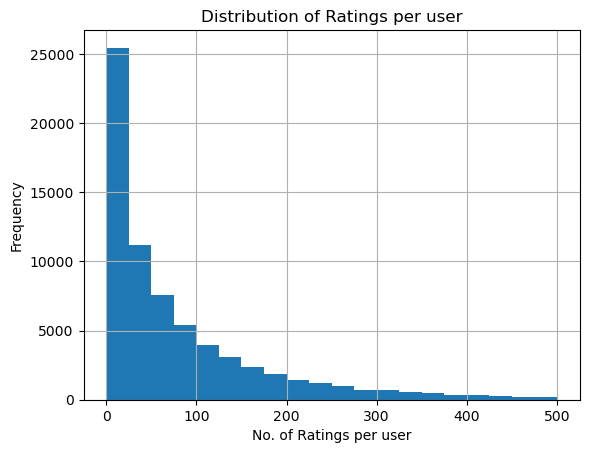

In [70]:
# Avg user has rated about 91 items 
# plot - histogram -no.of ratings per user
ratings_per_user.hist(bins=20, range=(0,500))
plt.xlabel('No. of Ratings per user')
plt.ylabel("Frequency")
plt.title('Distribution of Ratings per user')
plt.show()

In [72]:
# Cal no of ratings per anime
ratings_per_anime = ratings.groupby('anime_id')['rating'].count()

# Cal mean
mean_ratings_per_anime = statistics.mean(ratings_per_anime.tolist())
mean_ratings_per_anime

638.3843054296364

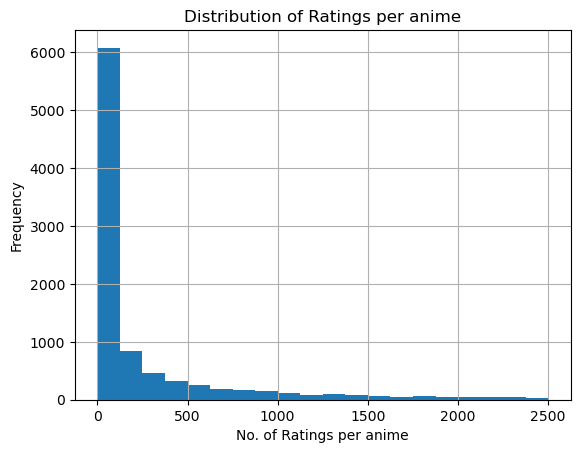

In [74]:
ratings_per_anime.hist(bins=20, range=(0,2500))
plt.xlabel('No. of Ratings per anime')
plt.ylabel("Frequency")
plt.title('Distribution of Ratings per anime')
plt.show()

In [76]:
# Filter ratings > 1000 to find popular anime and extract the ID of those 
# create a df
ratings_per_anime_df = pd.DataFrame(ratings_per_anime)
# filter 
filtered_ratings_per_anime_df = ratings_per_anime_df[ratings_per_anime_df.rating >= 1000]
# extract the indices of those anime
popular_anime = filtered_ratings_per_anime_df.index.tolist()

In [78]:
# create a list of profilic users - user who have given rating >= 500
ratings_per_user_df = pd.DataFrame(ratings_per_user)
# Filter 
filtered_ratings_per_user_df = ratings_per_user_df[ratings_per_user_df.rating >= 500]
# Extract indices
profilic_users = filtered_ratings_per_user_df.index.tolist()

In [80]:
# ratings dataset some filteration
# Filter the dataset to incldue rating for only popular anime
filtered_ratings = ratings[ratings.anime_id.isin(popular_anime)]
# Further filter this -> include only ratings from profilic users
filtered_ratings = ratings[ratings.user_id.isin(profilic_users)]
len(filtered_ratings)

1005314

In [82]:
# Create a pivot table to construct user-item matrix
rating_matrix = filtered_ratings.pivot_table(index='user_id',columns='anime_id',values='rating')
# Fill missing values to 0
rating_matrix = rating_matrix.fillna(0)
rating_matrix.head()

anime_id,1,5,6,7,8,15,16,17,18,19,...,34238,34239,34240,34252,34283,34324,34325,34349,34367,34475
user_id,,,,,,,,,,,,,,,,,,,,,
226,8.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
271,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
294,7.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
392,7.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
446,9.0,8.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,...,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
# now we can find similar users
from sklearn.metrics.pairwise import cosine_similarity
import operator

def similar_users(user_id, matrix, k=3) :
    # retreieve user's vector from rating_matrix
    user = matrix[matrix.index == user_id]
    # exclude user vector from rating matrix
    other_users = matrix[matrix.index != user_id]
    # Cal cosine similarity b/w user and other_users
    similarities = cosine_similarity(user, other_users)[0].tolist()
    # get the indices - user_ids of other users
    indices = other_users.index.tolist()
    # create a dictionary mepping indices to similairty scores
    index_similarity = dict(zip(indices, similarities))
    # sort the dictionary
    index_similarity_sorted = sorted(index_similarity.items(), key=operator.itemgetter(1))
    # [(5,0.98),(22,0.89)....]
    # Sort by the 2nd element in each tuple
    index_similarity_sorted.reverse()
    # Get the top k similar users
    top_users_similiarities =  index_similarity_sorted[:k]
    users = [u[0] for u in top_users_similiarities]
    return users
    

In [100]:
# test this
current_user = 226
# find indices of similar users
similar_users_indices = similar_users(current_user, rating_matrix)
print(similar_users_indices)

[30773, 39021, 45603]


In [104]:
# recommend items

def recommend_item(user_index, similar_users_indices, matrix, items=5) :
    # Select rows corresponding to similar users
    similar_users = matrix[matrix.index.isin(similar_users_indices)]
    # cal mean rating
    similar_users = similar_users.mean(axis=0)
    # convert it into a df
    similar_users_df = pd.DataFrame(similar_users, columns=['mean'])
    # select the target users rating
    user_df = matrix[matrix.index==user_index]
    # transpose 
    user_df_transposed = user_df.transpose()
    user_df_transposed.columns = ['rating']
    # Filter out items that targeted user has already rated
    user_df_transposed = user_df_transposed[user_df_transposed['rating'] == 0]
    # extract the anime_ids of unseen items
    anime_unseen =  user_df_transposed.index.tolist()
    # filter the df to include only ratings for unseen items
    similar_users_df_filtered = similar_users_df[similar_users_df.index.isin(anime_unseen)]
    # sort the df be mean rating in desc order
    similar_users_df_ordered = similar_users_df.sort_values(by='mean',ascending=False)
    # select the top n items with highest mean rating
    top_n_anime = similar_users_df_ordered.head(items)
    top_n_anime_indices =  top_n_anime.index.tolist()
    # retreive information from anime dataset
    anime_information = animes[animes['anime_id'].isin(top_n_anime_indices)]
    return anime_information
recommend_item(226, similar_users_indices, rating_matrix)

,anime_id,name,genre,type,episodes,rating,members
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855
39,12365,Bakuman. 3rd Season,"Comedy, Drama, Romance, Shounen",TV,25.0,8.71,133620
87,10030,Bakuman. 2nd Season,"Comedy, Drama, Romance, Shounen",TV,25.0,8.53,151561
131,4224,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25.0,8.45,633817
184,7674,Bakuman.,"Comedy, Romance, Shounen",TV,25.0,8.35,246899
